In [7]:
import os
import json

def read_json(filepath):
    try:
        with open(filepath, "r", encoding="utf-8") as f:
            data = json.load(f)
        print(f"--- Reading: {filepath} ---")
        print(f" Type: {type(data)}")
        if isinstance(data, dict):
            print(f" Keys: {list(data.keys())}\n")
        elif isinstance(data, list):
            print(f" Length: {len(data)}\n")
        else:
            print(" Unexpected JSON structure\n")
    except json.JSONDecodeError:
        print(f"--- Reading: {filepath} ---")
        print(" Error: Invalid JSON\n")
    except Exception as e:
        print(f"--- Reading: {filepath} ---")
        print(f" Error: {e}\n")

def traverse_directory(root):
    for dirpath, _, filenames in os.walk(root):
        for file in filenames:
            if file.endswith(".json"):
                filepath = os.path.join(dirpath, file)
                read_json(filepath)

if __name__ == "__main__":
    archive_path = r"C:\Users\LIGHTRQX\Desktop\archive"
    traverse_directory(archive_path)


--- Reading: C:\Users\LIGHTRQX\Desktop\archive\dataset_description.json ---
 Type: <class 'dict'>
 Keys: ['Name', 'BIDSVersion', 'Authors', 'DatasetDOI', 'License']

--- Reading: C:\Users\LIGHTRQX\Desktop\archive\participants.json ---
 Type: <class 'dict'>
 Keys: ['participant_id', 'age', 'gender', 'hand', 'MMSE', 'NAART', 'disease_duration', 'rl_deficits', 'notes']

--- Reading: C:\Users\LIGHTRQX\Desktop\archive\task-rest_beh.json ---
 Type: <class 'dict'>
 Keys: ['trial']

--- Reading: C:\Users\LIGHTRQX\Desktop\archive\sub-hc1\ses-hc\beh\sub-hc1_ses-hc_task-rest_beh.json ---
 Type: <class 'dict'>
 Keys: ['meds', 'questionairres']

--- Reading: C:\Users\LIGHTRQX\Desktop\archive\sub-hc1\ses-hc\eeg\sub-hc1_ses-hc_task-rest_eeg.json ---
 Type: <class 'dict'>
 Keys: ['TaskName', 'Manufacturer', 'PowerLineFrequency', 'SamplingFrequency', 'SoftwareFilters', 'RecordingDuration', 'RecordingType', 'EEGReference', 'EEGGround', 'EEGPlacementScheme', 'EEGChannelCount', 'EOGChannelCount', 'ECGChan

In [16]:
import mne
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

# Path to your archive folder
base_path = r"C:\Users\LIGHTRQX\Desktop\archive"

# Find all BDF files recursively
bdf_paths = glob.glob(os.path.join(base_path, "sub-*/ses-*/eeg/*.bdf"))

# Output folder for PSD plots
output_folder = os.path.join(base_path, "PSD_Plots")
os.makedirs(output_folder, exist_ok=True)

# Loop over all BDF files
for path in bdf_paths:
    try:
        print(f"Processing {path}...")
        raw = mne.io.read_raw_bdf(path, preload=True)
        
        # Compute PSD using Welch method
        psd = raw.compute_psd(fmin=0.5, fmax=50, n_fft=2048)
        psd_data = psd.get_data()  # shape: (n_channels, n_freqs)
        freqs = psd.freqs

        # Plot PSD for first 10 EEG channels
        plt.figure(figsize=(12, 6))
        channels_to_plot = min(10, psd_data.shape[0])
        for ch in range(channels_to_plot):
            plt.semilogy(freqs, psd_data[ch], label=raw.ch_names[ch])
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("PSD (V²/Hz)")
        plt.title(f"PSD - {os.path.basename(path)}")
        plt.legend()
        plt.tight_layout()

        # Save plot
        plot_name = os.path.join(output_folder, os.path.basename(path).replace(".bdf", "_PSD.png"))
        plt.savefig(plot_name)
        plt.close()
        print(f"Saved plot to {plot_name}")
        
    except Exception as e:
        print(f"Failed {path}: {e}")

print("Processing complete for all participants.")


Processing C:\Users\LIGHTRQX\Desktop\archive\sub-hc1\ses-hc\eeg\sub-hc1_ses-hc_task-rest_eeg.bdf...
Extracting EDF parameters from C:\Users\LIGHTRQX\Desktop\archive\sub-hc1\ses-hc\eeg\sub-hc1_ses-hc_task-rest_eeg.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 98303  =      0.000 ...   191.998 secs...
Effective window size : 4.000 (s)
Saved plot to C:\Users\LIGHTRQX\Desktop\archive\PSD_Plots\sub-hc1_ses-hc_task-rest_eeg_PSD.png
Processing C:\Users\LIGHTRQX\Desktop\archive\sub-hc10\ses-hc\eeg\sub-hc10_ses-hc_task-rest_eeg.bdf...
Extracting EDF parameters from C:\Users\LIGHTRQX\Desktop\archive\sub-hc10\ses-hc\eeg\sub-hc10_ses-hc_task-rest_eeg.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 102911  =      0.000 ...   200.998 secs...
Effective window size : 4.000 (s)
Saved plot to C:\Users\LIGHTRQX\Desktop\archive\PSD_Plots\sub-hc10_ses-hc_task-rest_eeg_PSD.png
Processing C:\User

Extracting EDF parameters from C:\Users\LIGHTRQX\Desktop\archive\sub-hc1\ses-hc\eeg\sub-hc1_ses-hc_task-rest_eeg.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 98303  =      0.000 ...   191.998 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Effective window size : 4.000 (s)
Extracting EDF parameters from C:\Users\LIGHTRQX\Desktop\archive\sub-hc10\ses-hc\eeg\sub-hc10_ses-hc_task-rest_eeg.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 102911  =      0.000 ...   200.998 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Effective window size : 4.000 (s)
Extracting EDF parameters from C:\Users\LIGHTRQX\Desktop\archive\sub-hc18\ses-hc\eeg\sub-hc18_ses-hc_task-rest_eeg.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 95231  =      0.000 ...   185.998 secs

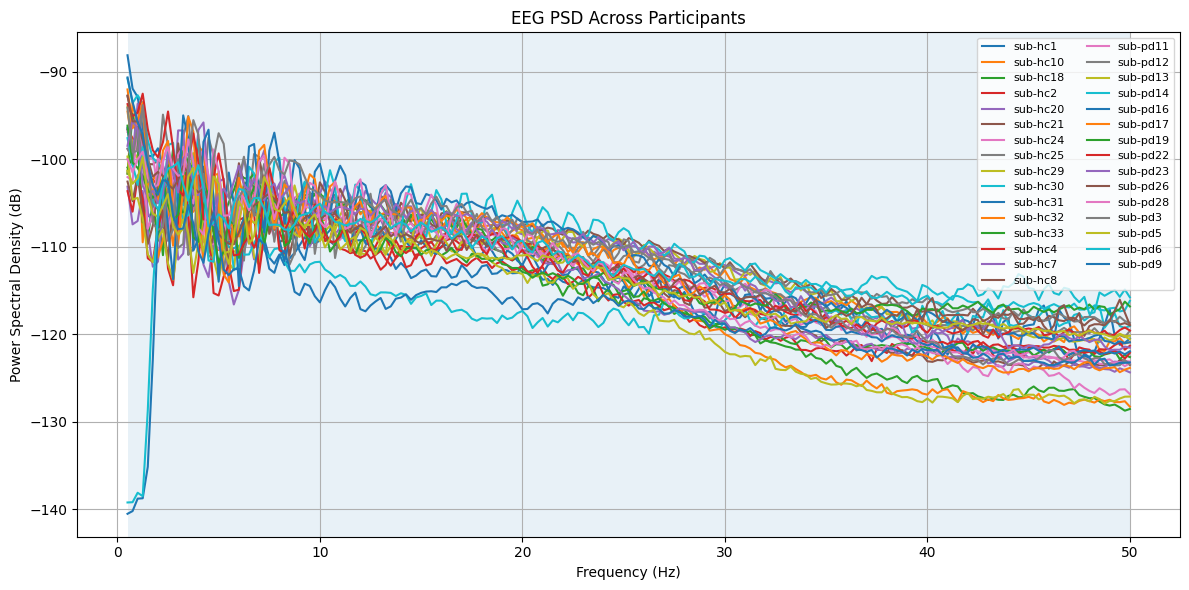

In [18]:
import os
import mne
import matplotlib.pyplot as plt
import numpy as np

data_dir = r"C:\Users\LIGHTRQX\Desktop\archive"
participants = [f for f in os.listdir(data_dir) if f.startswith("sub-")]

bands = {"Delta": (0.5,4), "Theta": (4,8), "Alpha": (8,13), "Beta": (13,30), "Gamma": (30,50)}

plt.figure(figsize=(12,6))

for sub in participants:
    eeg_path = os.path.join(data_dir, sub, "ses-hc" if "hc" in sub else "ses-on", "eeg")
    files = [f for f in os.listdir(eeg_path) if f.endswith(".bdf")]
    if not files: continue
    raw = mne.io.read_raw_bdf(os.path.join(eeg_path, files[0]), preload=True)
    raw.pick_types(eeg=True)
    
    psd = raw.compute_psd(fmin=0.5, fmax=50, n_fft=2048)
    freqs = psd.freqs
    mean_psd = psd.get_data().mean(axis=0)
    
    plt.plot(freqs, 10*np.log10(mean_psd), label=sub)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (dB)")
plt.title("EEG PSD Across Participants")
plt.legend(fontsize=8, ncol=2)
plt.grid(True)

for name, (fmin, fmax) in bands.items():
    plt.axvspan(fmin, fmax, alpha=0.1, label=name)

plt.tight_layout()
plt.show()
